## Phase 0 : Téléchargement du dataset via kagglehub.

Dataset : Credit Card Fraud Detection (ULB)
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [1]:
!pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Téléchargement via kagglehub (cache automatique)
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
path = Path(path)
print(f"Cache kagglehub : {path}")

Cache kagglehub : C:\Users\abedja\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [4]:
# Copie dans data/
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

src_csv = next(path.glob("*.csv"))
dest_csv = DATA_DIR / "creditcard.csv"

shutil.copy(src_csv, dest_csv)
print(f"Dataset copié : {dest_csv}")
print(f"Taille : {dest_csv.stat().st_size / 1e6:.1f} MB")

Dataset copié : data\creditcard.csv
Taille : 150.8 MB


In [5]:
# Vérification rapide
df = pd.read_csv(dest_csv, nrows=5)
print(f"Colonnes ({len(df.columns)}) :", list(df.columns))
df.head()

Colonnes (31) : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Phase 1 : Préparation des données & Split train/val/test

Exploratory Data Analysis (EDA)

In [6]:
df = pd.read_csv("data/creditcard.csv")
print(f"Shape : {df.shape}")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"\nDistribution de la cible :")
print(df["Class"].value_counts())
print(f"\nTaux de fraude : {df['Class'].mean()*100:.3f}%")

Shape : (284807, 31)
Valeurs manquantes : 0

Distribution de la cible :
Class
0    284315
1       492
Name: count, dtype: int64

Taux de fraude : 0.173%


Distribution des classes

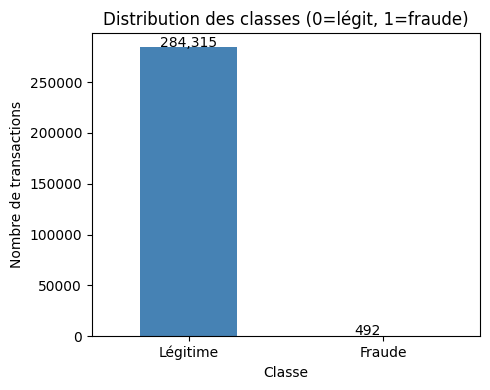

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Class"].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "crimson"])
ax.set_title("Distribution des classes (0=légit, 1=fraude)")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre de transactions")
ax.set_xticklabels(["Légitime", "Fraude"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}", (p.get_x() + 0.1, p.get_height() + 500))
plt.tight_layout()
plt.show()

Distribution du montant par classe

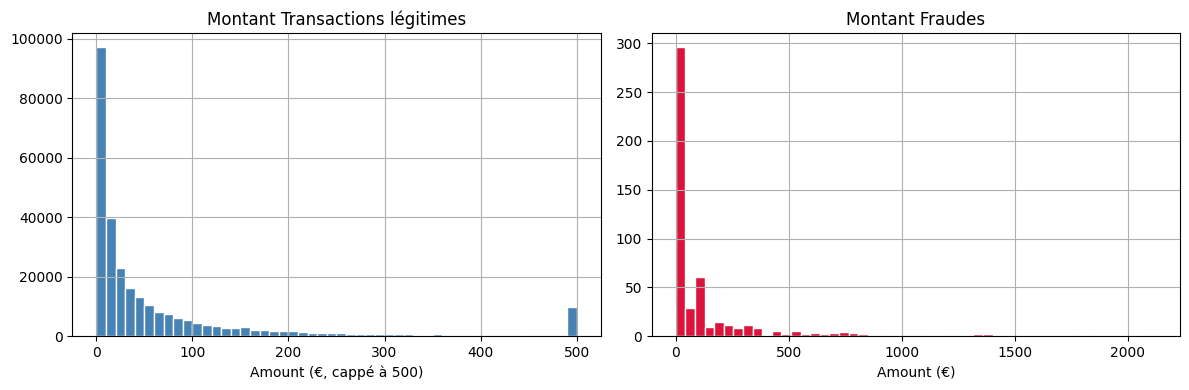

Montant moyen légitime : 88.29€
Montant moyen fraude   : 122.21€


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df["Class"] == 0]["Amount"].clip(upper=500).hist(
    bins=50, ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Montant Transactions légitimes")
axes[0].set_xlabel("Amount (€, cappé à 500)")

df[df["Class"] == 1]["Amount"].hist(
    bins=50, ax=axes[1], color="crimson", edgecolor="white"
)
axes[1].set_title("Montant Fraudes")
axes[1].set_xlabel("Amount (€)")

plt.tight_layout()
plt.show()

print(f"Montant moyen légitime : {df[df['Class']==0]['Amount'].mean():.2f}€")
print(f"Montant moyen fraude   : {df[df['Class']==1]['Amount'].mean():.2f}€")

Corrélations des features V avec Class :

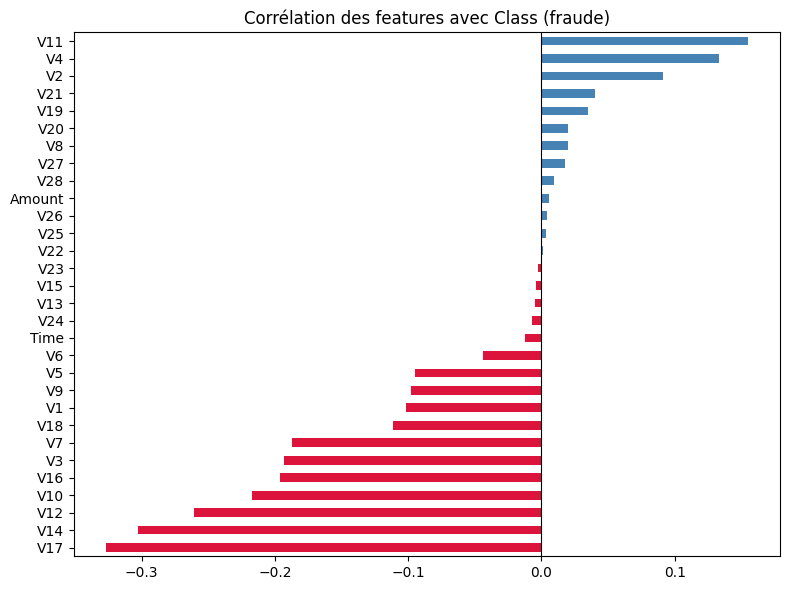

In [9]:
correlations = df.corr()["Class"].drop("Class").sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
correlations.plot(kind="barh", ax=ax, color=[
    "crimson" if v < 0 else "steelblue" for v in correlations
])
ax.set_title("Corrélation des features avec Class (fraude)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

Nettoyage 

In [10]:
from sklearn.preprocessing import StandardScaler

# Pas de valeurs manquantes (vérifié en EDA), on scale Amount et Time
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])

df = df.drop(columns=["Amount", "Time"])

X = df.drop(columns=["Class"])
y = df["Class"]

print(f"Features : {X.shape[1]} | Samples : {X.shape[0]}")

Features : 30 | Samples : 284807


Split train/val/test 

In [11]:
from sklearn.model_selection import train_test_split

def split_train_val_test(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """Découpe X, y en trois jeux : train, validation, test.
    Doit renvoyer 6 objets : X_train, X_val, X_test, y_train, y_val, y_test.
    Les proportions doivent rester respectées (utiliser stratify=y).
    """
    # Premier split : isoler le test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    # Recalculer la proportion val sur le reste
    val_size_adjusted = val_size / (1 - test_size)

    # Deuxième split : isoler la validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(X, y)

print(f"Train : {len(X_train)} | Validation : {len(X_val)} | Test : {len(X_test)}")
print(f"\nTaux de fraude, Train : {y_train.mean()*100:.3f}% | Val : {y_val.mean()*100:.3f}% | Test : {y_test.mean()*100:.3f}%")

Train : 170883 | Validation : 56962 | Test : 56962

Taux de fraude, Train : 0.173% | Val : 0.174% | Test : 0.172%


Checkpoints qualité

In [12]:

print("\ncas normal")
# Cas normal : les tailles s'additionnent
taille = len(X_train) + len(X_val) + len(X_test)
print(f'Taille addition : {taille}')
print(len(X))

print("\ncas limite")
# Cas limite : val_size=0 doit lever une erreur claire
try:
    split_train_val_test(X, y, val_size=0)
except Exception as e:
    print("val_size=0 -> erreur capturée :")
    print(e)

print("\ncas adversarial")
# Cas adversarial : stratify garde bien les proportions sur dataset déséquilibré
for nom, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    assert y_split.sum() > 0, f"Aucune fraude dans {nom} : stratify a échoué !"
    print(f"{nom} : {y_split.sum()} fraudes sur {len(y_split)} ({y_split.mean()*100:.3f}%)")


cas normal
Taille addition : 284807
284807

cas limite
val_size=0 -> erreur capturée :
The 'test_size' parameter of train_test_split must be a float in the range (0.0, 1.0), an int in the range [1, inf) or None. Got 0.0 instead.

cas adversarial
Train : 295 fraudes sur 170883 (0.173%)
Val : 99 fraudes sur 56962 (0.174%)
Test : 98 fraudes sur 56962 (0.172%)


## Phase 2 : Bootstrap et bagging, comprendre le rééchantillonnage

Fonction bootstrap_scores

In [13]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def bootstrap_scores(modele, X, y, n_iterations=30, random_state=42):
    """Évalue la stabilité d'un modèle par bootstrap.
    Pour chaque itération : tirer un échantillon AVEC REMISE de même taille
    que X, entraîner, évaluer sur les points NON tirés (out-of-bag).
    Doit renvoyer la liste des scores et afficher moyenne et écart-type.
    """
    rng = np.random.default_rng(random_state)
    scores = []
    n = len(X)
    X_arr = np.array(X)
    y_arr = np.array(y)

    for _ in range(n_iterations):
        # Tirage avec remise
        indices_boot = rng.choice(n, size=n, replace=True)
        # Out-of-bag : indices jamais tirés
        indices_oob = np.array(list(set(range(n)) - set(indices_boot)))

        if len(indices_oob) == 0:
            # Cas rare : échantillon OOB vide, on skip
            continue

        X_boot, y_boot = X_arr[indices_boot], y_arr[indices_boot]
        X_oob, y_oob = X_arr[indices_oob], y_arr[indices_oob]

        modele.fit(X_boot, y_boot)
        scores.append(modele.score(X_oob, y_oob))

    print(f"Score moyen sur {len(scores)} bootstraps : {np.mean(scores):.3f} (± {np.std(scores):.3f})")
    return scores

Test et checkpoints

In [14]:
modele = LogisticRegression(max_iter=1000, random_state=42)

# Cas normal
scores = bootstrap_scores(modele, X_train, y_train, n_iterations=30)

# Cas adversarial : sans replace=True, écart-type quasi nul
rng = np.random.default_rng(42)
indices_no_replace = rng.choice(len(X_train), size=len(X_train), replace=False)
print(f"\nSans remise, tous les indices uniques : {len(set(indices_no_replace)) == len(X_train)}")
print("OOB vide à chaque itération, bootstrap dégénéré")

# Cas limite : n_iterations=1 -> écart-type non affiché ou 0
scores_1 = bootstrap_scores(modele, X_train, y_train, n_iterations=1)
print(f"n_iterations=1, un seul score, écart-type : {np.std(scores_1):.3f}")

Score moyen sur 30 bootstraps : 0.999 (± 0.000)

Sans remise, tous les indices uniques : True
OOB vide à chaque itération, bootstrap dégénéré
Score moyen sur 1 bootstraps : 0.999 (± 0.000)
n_iterations=1, un seul score, écart-type : 0.000


## Phase 3 : Validation croisée k-fold

Fonction evaluer_en_cross_val

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import time

def evaluer_en_cross_val(modele, X, y, k=5):
    """Lance une validation croisée k-fold et résume les résultats.
    Doit afficher les k scores, leur moyenne et leur écart-type.
    Un grand écart-type entre folds = modèle instable, à signaler.
    """
    scores = cross_val_score(modele, X, y, cv=k, scoring="accuracy")
    print(f"Scores par fold : {scores}")
    print(f"Moyenne : {scores.mean():.3f} | Écart-type : {scores.std():.3f}", end="  ->  ")
    print("modèle stable" if scores.std() < 0.01 else "modèle instable, écart-type élevé")
    return scores

Checkpoints 

In [16]:
modele = LogisticRegression(max_iter=1000, random_state=42)

print("Cas normal")
# Cas normal : 5 folds
scores = evaluer_en_cross_val(modele, X_train, y_train, k=5)

print("\nCas limite")
# Cas limite : k=50 sur 500 samples, mesure du temps
print("\nk=50 sur 500 samples (extrait) :")
X_small = np.array(X_train)[:500]
y_small = np.array(y_train)[:500]
start = time.time()
evaluer_en_cross_val(modele, X_small, y_small, k=50)
print(f"Temps k=50 : {time.time() - start:.2f}s")

print("\nCas adversarial")
# Cas adversarial : cross_val_score standard vs StratifiedKFold
print("Sans stratification vs avec StratifiedKFold :")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(modele, X_train, y_train, cv=skf, scoring="recall")
scores_std = cross_val_score(modele, X_train, y_train, cv=5, scoring="recall")
print(f"Standard  recall par fold : {scores_std.round(3)}")
print(f"Stratifié recall par fold : {scores_strat.round(3)}")


Cas normal
Scores par fold : [0.99915148 0.99941481 0.99941481 0.99923923 0.99929775]
Moyenne : 0.999 | Écart-type : 0.000  ->  modèle stable

Cas limite

k=50 sur 500 samples (extrait) :


c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=50.
  warnings.warn(
c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\User

Scores par fold : [1.  1.  1.  1.  1.  1.  1.  0.9 1.  1.  1.  1.  1.  1.  1.  0.9 1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  nan]
Moyenne : nan | Écart-type : nan  ->  modèle instable, écart-type élevé
Temps k=50 : 0.55s

Cas adversarial
Sans stratification vs avec StratifiedKFold :
Standard  recall par fold : [0.627 0.712 0.712 0.627 0.644]
Stratifié recall par fold : [0.508 0.627 0.695 0.847 0.678]


## Phase 4 : Métriques métier : coût réel vs accuracy

Fonction rapport_metier

In [17]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def rapport_metier(y_true, y_pred, cout_fn=10, cout_fp=1):
    """Affiche la matrice de confusion et les métriques, puis calcule un
    coût métier total = (nb faux négatifs * cout_fn) + (nb faux positifs * cout_fp).
    Permet de comparer deux modèles sur l'argent perdu, pas sur l'accuracy.
    """
    matrice = confusion_matrix(y_true, y_pred)
    tn, fp, fn, vp = matrice.ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cout_total = fn * cout_fn + fp * cout_fp

    print(f"Matrice de confusion : TN={tn} | FP={fp} | FN={fn} | VP={vp}")
    print(f"Précision={precision:.2f}  Recall={recall:.2f}  F1={f1:.2f}")
    print(f"Coût métier total = {fn} x {cout_fn} + {fp} x {cout_fp} = {cout_total}")
    return cout_total

Cas normal

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modele_A = LogisticRegression(max_iter=1000, random_state=42)
modele_B = RandomForestClassifier(n_estimators=100, random_state=42)

modele_A.fit(X_train, y_train)
modele_B.fit(X_train, y_train)

y_pred_A = modele_A.predict(X_val)
y_pred_B = modele_B.predict(X_val)

print("Modèle A (Logistic Regression) :")
cout_A = rapport_metier(y_val, y_pred_A)

print("\nModèle B (Random Forest) :")
cout_B = rapport_metier(y_val, y_pred_B)

ratio = cout_A / cout_B if cout_B > 0 else float("inf")
print(f"\nLe modèle {'A' if cout_A > cout_B else 'B'} coûte {ratio:.1f}x plus cher en fraudes ratées")

Modèle A (Logistic Regression) :
Matrice de confusion : TN=56852 | FP=11 | FN=46 | VP=53
Précision=0.83  Recall=0.54  F1=0.65
Coût métier total = 46 x 10 + 11 x 1 = 471

Modèle B (Random Forest) :
Matrice de confusion : TN=56859 | FP=4 | FN=29 | VP=70
Précision=0.95  Recall=0.71  F1=0.81
Coût métier total = 29 x 10 + 4 x 1 = 294

Le modèle A coûte 1.6x plus cher en fraudes ratées


Cas limite, modèle paresseux

In [19]:
# Modèle qui prédit toujours 0 : accuracy élevée, recall nul
import numpy as np

y_pred_paresseux = np.zeros(len(y_val), dtype=int)

print("Modèle paresseux (toujours 'pas de fraude') :")
print(f"Accuracy : {(y_pred_paresseux == y_val).mean()*100:.2f}%")
rapport_metier(y_val, y_pred_paresseux)

Modèle paresseux (toujours 'pas de fraude') :
Accuracy : 99.83%
Matrice de confusion : TN=56863 | FP=0 | FN=99 | VP=0
Précision=0.00  Recall=0.00  F1=0.00
Coût métier total = 99 x 10 + 0 x 1 = 990


np.int64(990)

Cas adversarial

In [20]:
# Collègue fier de ses 99% d'accuracy
print(f"\nModèle paresseux  accuracy=99%  |  ", end="")
rapport_metier(y_val, y_pred_paresseux)

print(f"\nModèle A (LR)     |  ", end="")
rapport_metier(y_val, y_pred_A)

print(f"\nModèle B (RF)     |  ", end="")
rapport_metier(y_val, y_pred_B)


Modèle paresseux  accuracy=99%  |  Matrice de confusion : TN=56863 | FP=0 | FN=99 | VP=0
Précision=0.00  Recall=0.00  F1=0.00
Coût métier total = 99 x 10 + 0 x 1 = 990

Modèle A (LR)     |  Matrice de confusion : TN=56852 | FP=11 | FN=46 | VP=53
Précision=0.83  Recall=0.54  F1=0.65
Coût métier total = 46 x 10 + 11 x 1 = 471

Modèle B (RF)     |  Matrice de confusion : TN=56859 | FP=4 | FN=29 | VP=70
Précision=0.95  Recall=0.71  F1=0.81
Coût métier total = 29 x 10 + 4 x 1 = 294


np.int64(294)

## Phase 5 : Sérialisation du modèle et API Flask

Sauvegarde du modèle et scaler

In [28]:
import joblib
from sklearn.preprocessing import StandardScaler

def sauvegarder_modele(modele, scaler, chemin="modele.joblib"):
    """Sauvegarde le modèle ET le scaler ensemble (sinon les prédictions
    en prod seront fausses : il faut normaliser pareil qu'à l'entraînement).
    """
    joblib.dump({"modele": modele, "scaler": scaler}, chemin)
    print(f"Modèle sauvegardé : {chemin}")

# On sauvegarde le champion (Random Forest, coût métier 294)
scaler_full = StandardScaler()
scaler_full.fit(X_train)
sauvegarder_modele(modele_B, scaler_full, chemin="modele.joblib")

Modèle sauvegardé : modele.joblib


API Flask

In [22]:
!pip install flask -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from flask import Flask, request, jsonify
import numpy as np

app = Flask(__name__)

artefact = joblib.load("modele.joblib")
modele_charge = artefact["modele"]
scaler_charge = artefact["scaler"]

N_FEATURES = X_train.shape[1]  # 30 features

@app.route("/predict", methods=["POST"])
def predict():
    """Reçoit un JSON {"features": [...]}, renvoie {"prediction": ..., "proba": ..., "label": ...}.
    Lit le JSON, normalise avec le scaler, prédit, renvoie le résultat.
    prediction : 0 = légitime, 1 = fraude
    """
    data = request.get_json()

    if not data or "features" not in data:
        return jsonify({"error": "Clé 'features' manquante"}), 400

    features = data["features"]

    if not isinstance(features, list) or len(features) == 0:
        return jsonify({"error": "features doit être une liste non vide"}), 400

    if len(features) != N_FEATURES:
        return jsonify({"error": f"Attendu {N_FEATURES} features, reçu {len(features)}"}), 400

    try:
        features_array = np.array(features, dtype=float).reshape(1, -1)
    except (ValueError, TypeError):
        return jsonify({"error": "features doit contenir uniquement des nombres"}), 400

    features_scaled = scaler_charge.transform(features_array)
    prediction = int(modele_charge.predict(features_scaled)[0])
    proba = float(modele_charge.predict_proba(features_scaled)[0][1])
    label = "fraude" if prediction == 1 else "legitime"

    return jsonify({"prediction": prediction, "proba": round(proba, 4), "label": label})

Checkpoints sans lancer le serveur

In [30]:
with app.test_client() as client:

    # Cas normal : une transaction légitime du jeu de validation
    features_legitime = X_val.iloc[0].tolist()
    response = client.post("/predict", json={"features": features_legitime})
    print("Cas normal (légitime) :", response.get_json())

    # Cas normal : une vraie fraude du jeu de validation
    fraude_idx = y_val[y_val == 1].index[0]
    features_fraude = X_val.loc[fraude_idx].tolist()
    response = client.post("/predict", json={"features": features_fraude})
    print("Cas normal (fraude)   :", response.get_json())

    # Cas limite : clé features manquante
    response = client.post("/predict", json={"data": features_legitime})
    print("Cas limite (clé manquante)       :", response.status_code, response.get_json())

    # Cas limite : mauvais nombre de features
    response = client.post("/predict", json={"features": [0.5] * 10})
    print("Cas limite (mauvais nb features) :", response.status_code, response.get_json())

    # Cas adversarial : texte au lieu de nombres
    response = client.post("/predict", json={"features": ["abc"] * N_FEATURES})
    print("Cas adversarial (texte)          :", response.status_code, response.get_json())

    # Cas adversarial : tableau vide
    response = client.post("/predict", json={"features": []})
    print("Cas adversarial (vide)           :", response.status_code, response.get_json())

Cas normal (légitime) : {'label': 'legitime', 'prediction': 0, 'proba': 0.0}
Cas normal (fraude)   : {'label': 'fraude', 'prediction': 1, 'proba': 0.95}
Cas limite (clé manquante)       : 400 {'error': "Clé 'features' manquante"}
Cas limite (mauvais nb features) : 400 {'error': 'Attendu 30 features, reçu 10'}
Cas adversarial (texte)          : 400 {'error': 'features doit contenir uniquement des nombres'}
Cas adversarial (vide)           : 400 {'error': 'features doit être une liste non vide'}


c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\abedja\IPSSI4\arene-des-algos-Awadi_BEDJA\venv312\Lib\site-packages

## Phase 6 : WebApp Streamlit de prédiction
Lancement : `streamlit run app.py`

In [31]:
!pip install streamlit -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# affiche une transaction légitime et une fraude
print("Légitime :", X_val.iloc[0].tolist())
print("Fraude   :", X_val.loc[y_val[y_val==1].index[0]].tolist())

Légitime : [2.12682803272248, -0.395370282391653, -3.18440546332505, -0.758266636023627, 0.739843810562344, -1.55320593978296, 0.726657532420872, -0.718870743005694, -1.30137433402813, 0.353529883385011, -0.335423484764407, -0.356032191870578, 1.13082070248585, -1.04577083753056, -0.481740469036202, 0.492175967578871, 1.33985708175871, -1.25719521126153, 0.615577198087973, 0.273101979262796, 0.463777224564467, 1.24718871747798, -0.338080919199017, 0.612232132826104, 0.818289684767577, 0.262774327022374, -0.0959263793163722, -0.041496180868395, 0.0798832844224751, 0.9494415642613911]
Fraude   : [-12.3396031574122, 4.48826730168204, -16.5870729373632, 10.1072738734101, -10.4201989827431, 0.130669811857349, -15.6003233044816, -1.15769598093331, -5.3046309683427, -12.9389293107706, 8.80568196718575, -13.5561301301468, 1.16546376028499, -9.80988150207055, 0.369987279150665, -9.50521044515487, -17.5420303090874, -6.79263778723153, 2.06937744931751, -0.0855014634055812, -2.0896096332232, 1.74

Export des transactions de test

In [36]:
import os
os.makedirs("data/test_samples", exist_ok=True)

# Exporter depuis df original (avant scaling) pour avoir Amount et Time
df_original = pd.read_csv("data/creditcard.csv")
val_indices = y_val.index

legitimes_idx = y_val[y_val == 0].index[:3]
fraudes_idx = y_val[y_val == 1].index[:3]

for i, idx in enumerate(legitimes_idx):
    df_original.loc[[idx]].to_csv(f"data/test_samples/legitime_{i+1}.csv", index=False)

for i, idx in enumerate(fraudes_idx):
    df_original.loc[[idx]].to_csv(f"data/test_samples/fraude_{i+1}.csv", index=False)

pd.concat([df_original.loc[legitimes_idx], df_original.loc[fraudes_idx]]).to_csv(
    "data/test_samples/batch_6transactions.csv", index=False)
